In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

train_df = pd.read_csv("../processed_data/pv_train.csv")
val_df = pd.read_csv("../processed_data/pv_val.csv")
test_df = pd.read_csv("../processed_data/pv_test.csv")

all_df = pd.concat([train_df, val_df, test_df])

class_names = sorted(all_df["class_name"].unique())
num_classes = len(class_names)

print("Classes:", num_classes)
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Classes: 38
Train: 38011
Validation: 8148
Test: 8146


In [2]:
IMG_SIZE = 224
BATCH_SIZE = 16

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)

    return image, label


def make_dataset(df, training=False):
    paths = df["image_path"].values
    labels = df["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=42
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

In [3]:
# training - only augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [4]:
#loading pre trained mobilenetv2 model
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)


In [5]:
# freeing the model 
base_model.trainable = False

print("Base model trainable:", base_model.trainable)

Base model trainable: False


In [6]:
#building our 38 class model
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax"
)(x)

mobilenet_model = keras.Model(
    inputs,
    outputs
)

mobilenet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
#compile
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
# runtime
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="../Models/mobilenetv2_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [9]:
import os

print(
    os.path.abspath(
        "../Models/mobilenetv2_best.keras"
    )
)

d:\FruitDiseaseDissertation\Models\mobilenetv2_best.keras


In [10]:
#training the model
import time

start_time = time.time()

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

mobilenet_training_time = time.time() - start_time

print(
    f"Training time: "
    f"{mobilenet_training_time / 60:.2f} minutes"
)

Epoch 1/15


d:\FruitDiseaseDissertation\tf_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2376/2376 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8519 - loss: 0.5130
Epoch 1: val_loss improved from None to 0.25156, saving model to ../Models/mobilenetv2_best.keras

Epoch 1: finished saving model to ../Models/mobilenetv2_best.keras
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 1286s 533ms/step - accuracy: 0.8519 - loss: 0.5130 - val_accuracy: 0.9235 - val_loss: 0.2516 - learning_rate: 0.0010
Epoch 2/15
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9152 - loss: 0.2668
Epoch 2: val_loss improved from 0.25156 to 0.20741, saving model to ../Models/mobilenetv2_best.keras

Epoch 2: finished saving model to ../Models/mobilenetv2_best.keras
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 1229s 517ms/step - accuracy: 0.9152 - loss: 0.2668 - val_accuracy: 0.9359 - val_loss: 0.2074 - learning_rate: 0.0010
Epoch 3/15
2376/2376 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9223 - loss: 0.2384
Epoch 3: val_loss improved from 0.20741 to 0.18070, saving model to ../Models/mobilenetv2_best.keras

Epoch 3:

KeyboardInterrupt: 

In [11]:
best_mobilenet = keras.models.load_model(
    "../Models/mobilenetv2_best.keras"
)

test_loss, test_accuracy = best_mobilenet.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

510/510 ━━━━━━━━━━━━━━━━━━━━ 228s 436ms/step - accuracy: 0.9505 - loss: 0.1518
Test Loss: 0.1518125832080841
Test Accuracy: 0.9505278468132019


In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

y_true_mobile = np.concatenate(
    [y.numpy() for x, y in test_ds]
)

y_prob_mobile = best_mobilenet.predict(test_ds)

y_pred_mobile = np.argmax(
    y_prob_mobile,
    axis=1
)

mobile_report = classification_report(
    y_true_mobile,
    y_pred_mobile,
    target_names=class_names,
    digits=4,
    output_dict=True
)

mobile_report_df = pd.DataFrame(
    mobile_report
).transpose()

mobile_report_df.to_csv(
    "../report/mobilenetv2_classification_report.csv"
)

mobile_report_df

510/510 ━━━━━━━━━━━━━━━━━━━━ 204s 394ms/step


,precision,recall,f1-score,support
Apple___Apple_scab,0.956044,0.925532,0.940541,94.000000
Apple___Black_rot,0.977273,0.924731,0.950276,93.000000
Apple___Cedar_apple_rust,1.000000,0.951220,0.975000,41.000000
Apple___healthy,0.983539,0.967611,0.975510,247.000000
Blueberry___healthy,1.000000,1.000000,1.000000,225.000000
Cherry_(including_sour)___Powdery_mildew,0.987421,0.993671,0.990536,158.000000
Cherry_(including_sour)___healthy,0.984615,1.000000,0.992248,128.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.759494,0.779221,0.769231,77.000000
Corn_(maize)___Common_rust_,1.000000,1.000000,1.000000,179.000000
Corn_(maize)___Northern_Leaf_Blight,0.877551,0.871622,0.874576,148.000000


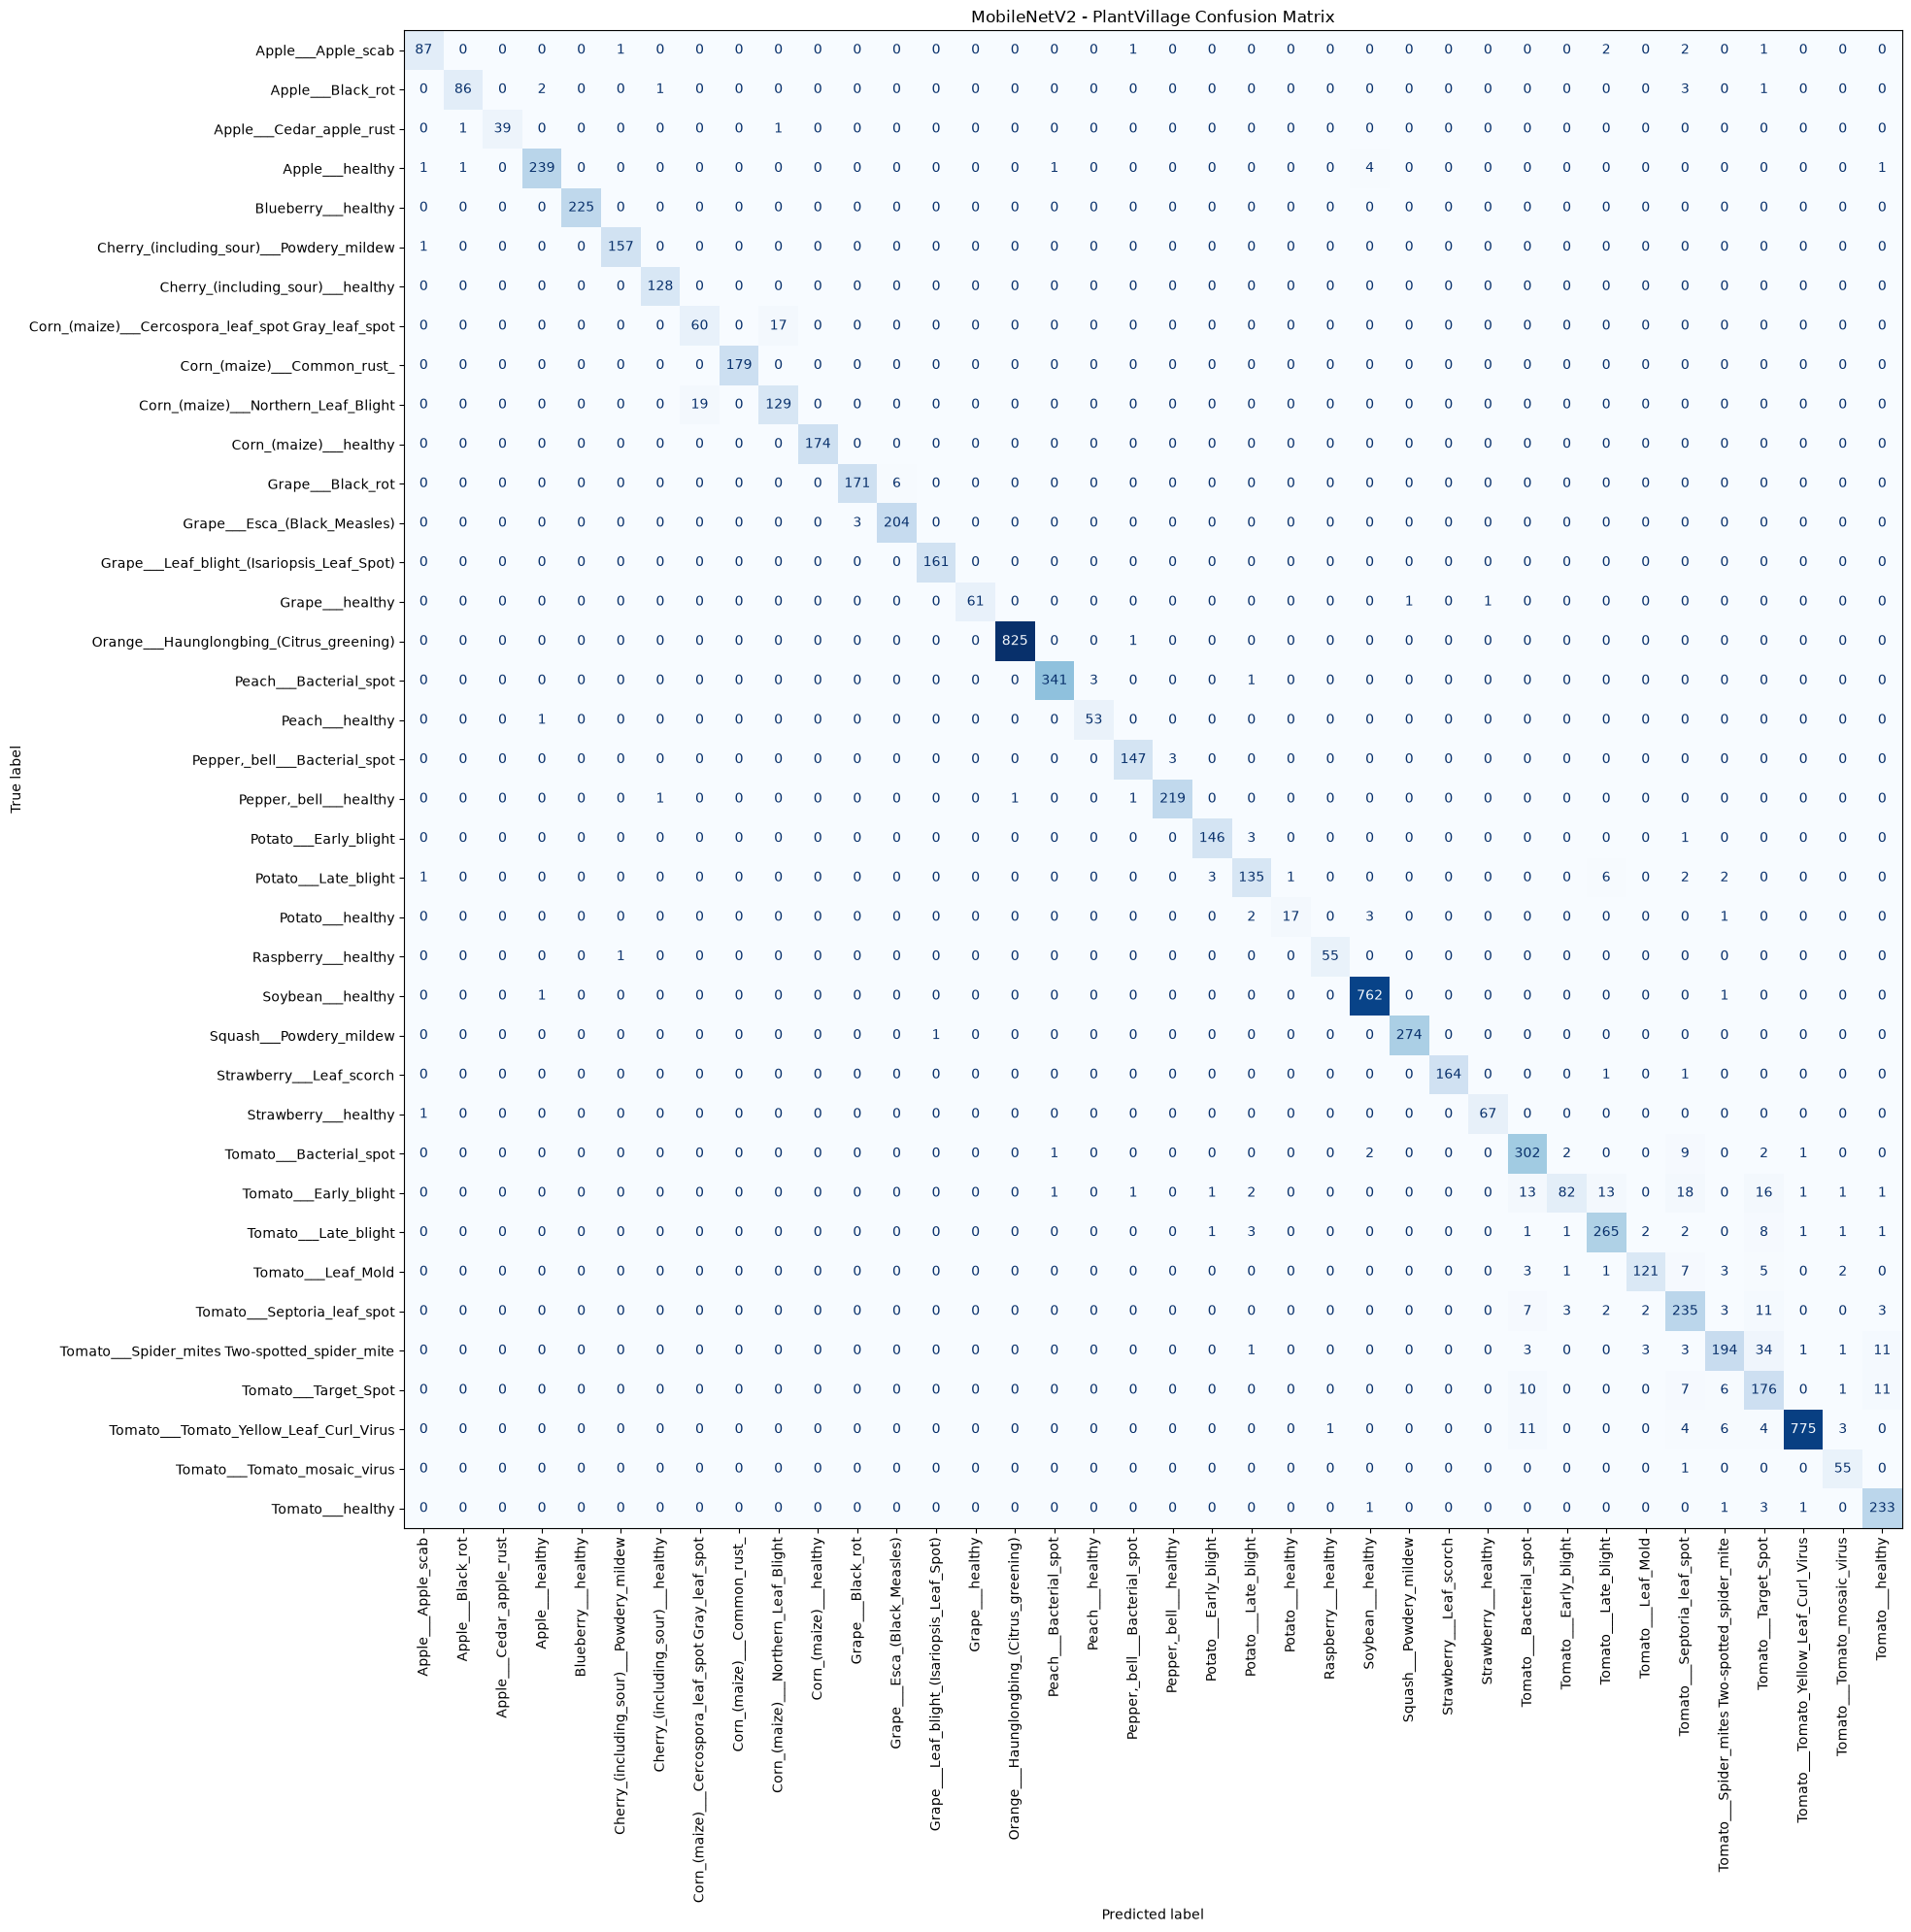

In [14]:
#condusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_mobile = confusion_matrix(y_true_mobile, y_pred_mobile)

fig, ax = plt.subplots(figsize=(20, 20))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mobile,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title("MobileNetV2 - PlantVillage Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../report/mobilenetv2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
#accuracy curve
plt.figure(figsize=(8, 5))

plt.plot(
    mobilenet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    mobilenet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "../report/mobilenetv2_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'mobilenet_history' is not defined

<Figure size 800x500 with 0 Axes>

In [17]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
BATCH_SIZE               int                       16
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
IMG_SIZE                 int                       224
all_df                   DataFrame                 Shape: (54305, 3)
ax                       Axes                      Axes(0.214609,0.210526;0.771307x0.771307)
base_model               Functional                <Functional name=mobilene<...>tv2_1.00_224, built=True>
best_mobilenet           Functional                <Functional name=functional_1, built=True>
callbacks                list                      n=3
class_names              list                      n=38
classification_report    function                  <function classification_<...>rt at 0x000001F1E454F1A0>
cm_mobile                ndarray                   38x38: 1444 elems, type `int64

In [18]:
history_objects = {
    name: value
    for name, value in globals().items()
    if isinstance(value, tf.keras.callbacks.History)
}

print(history_objects.keys())

dict_keys([])


In [19]:
epochs = list(range(1, 11))

train_accuracy = [
    0.8519,
    0.9152,
    0.9223,
    0.9252,
    0.9295,
    0.9382,
    0.9389,
    0.9413,
    0.9425,
    0.9414
]

train_loss = [
    0.5130,
    0.2668,
    0.2384,
    0.2260,
    0.2180,
    0.1899,
    0.1820,
    0.1795,
    0.1734,
    0.1733
]

val_accuracy = [
    0.9235,
    0.9359,
    0.9437,
    0.9375,
    0.9404,
    0.9510,
    0.9500,
    0.9504,
    0.9509,
    0.9536
]

val_loss = [
    0.2516,
    0.2074,
    0.1807,
    0.1898,
    0.1815,
    0.1614,
    0.1592,
    0.1577,
    0.1474,
    0.1440
]

In [21]:
import pandas as pd

history_df = pd.DataFrame({
    "epoch": epochs,
    "accuracy": train_accuracy,
    "loss": train_loss,
    "val_accuracy": val_accuracy,
    "val_loss": val_loss
})

history_df.to_csv(
    "../report/mobilenetv2_training_history.csv",
    index=False
)

history_df

,epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.8519,0.5130,0.9235,0.2516
1,2,0.9152,0.2668,0.9359,0.2074
2,3,0.9223,0.2384,0.9437,0.1807
3,4,0.9252,0.2260,0.9375,0.1898
4,5,0.9295,0.2180,0.9404,0.1815
5,6,0.9382,0.1899,0.9510,0.1614
6,7,0.9389,0.1820,0.9500,0.1592
7,8,0.9413,0.1795,0.9504,0.1577
8,9,0.9425,0.1734,0.9509,0.1474
9,10,0.9414,0.1733,0.9536,0.1440


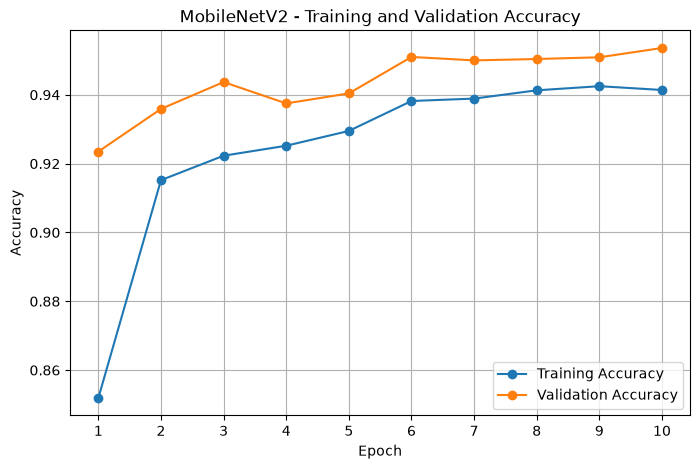

In [22]:
# accuracy curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Training and Validation Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.savefig(
    "../report/mobilenetv2_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

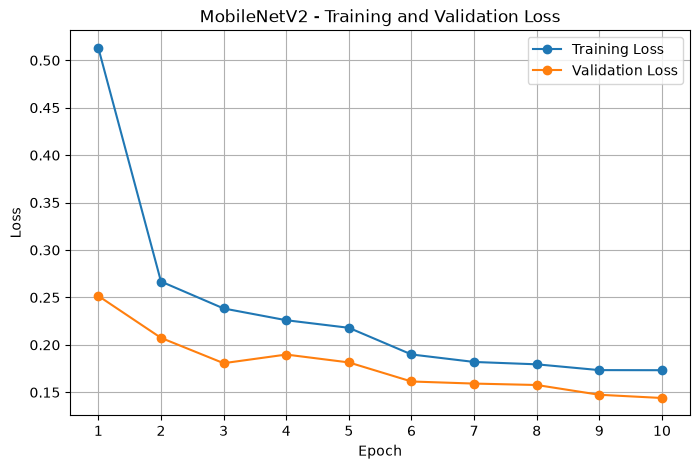

In [24]:
#loss curve
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Training and Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.savefig(
    "../report/mobilenetv2_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()